# Customer Churn Prediction

This notebook presents a comprehensive analysis of a customer churn dataset to identify key factors influencing customer retention and develop a predictive model. The objective is to build an accurate and reliable model that can assist in proactive customer retention strategies.

**Project Steps:**

*   **Data Loading and Initial Inspection:** Load the dataset and perform initial checks on its structure and content.
*   **Data Cleaning and Preprocessing:** Handle missing values, inconsistencies, and prepare the data for analysis.
*   **Exploratory Data Analysis (EDA):** Visualize and analyze the data to understand distributions, relationships, and identify potential churn factors.
*   **Feature Engineering:** Create new features or transform existing ones to improve model performance.
*   **Model Training and Evaluation:** Build and evaluate machine learning models for churn prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Data Loading and Initial Inspection

This section focuses on loading the customer churn dataset and performing initial checks to understand its structure, data types, and basic statistics.

In [2]:
data = pd.read_csv(r"C:\Files\Projects\customer-churn-predictor\data\WA_Fn-UseC_-Telco-Customer-Churn.csv").drop('customerID', axis=1)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data['TotalCharges'] = data['TotalCharges'].replace(' ', np.nan)

## Data Cleaning and Preprocessing

In this section, we will handle missing values, address inconsistencies, and prepare the data for subsequent analysis and model building.

In [4]:
data['TotalCharges'] = data['TotalCharges'].astype('float')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Handling Missing Values

First, we will identify and handle missing values in the dataset. The `TotalCharges` column contains some missing entries which we will address.

In [7]:
fill = data['tenure']*data['MonthlyCharges']
data['TotalCharges'] = data['TotalCharges'].fillna(fill)

## Exploratory Data Analysis (EDA)

This section involves visualizing and analyzing the data to understand the distribution of features, identify relationships between variables, and uncover potential factors influencing customer churn.

In [8]:
data.describe(exclude=['O'])

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Distribution of Numerical Features

We will visualize the distributions of numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges` to understand their spread and identify any patterns.

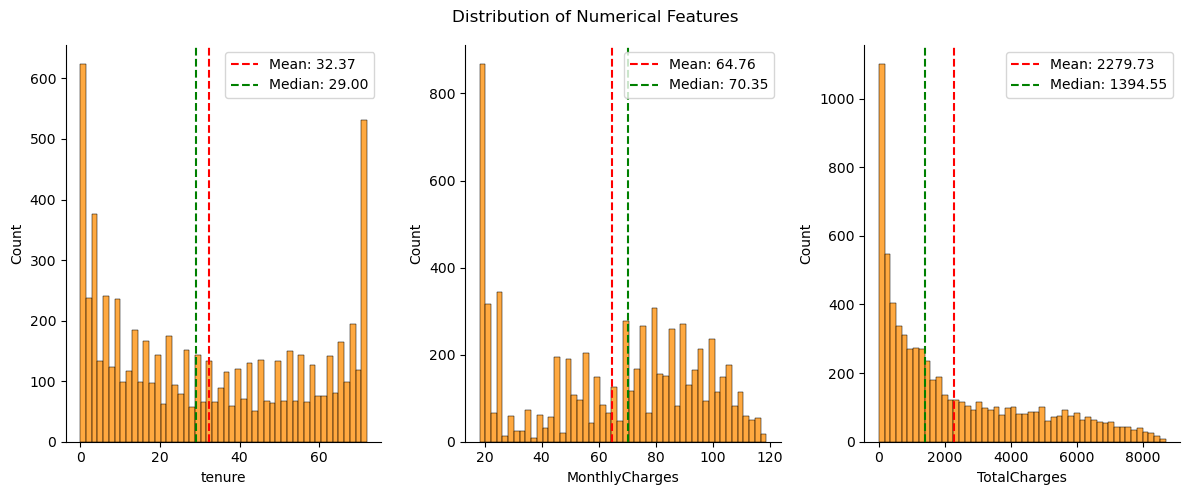

In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax = ax.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(data, x=col, color='darkorange', bins=50, ax=ax[i])
  ax[i].spines[['right', 'top']].set_visible(False)

  mean_val = data[col].mean()
  median_val = data[col].median()
  ax[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
  ax[i].axvline(median_val, color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {median_val:.2f}')
  ax[i].legend()


plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

### Relationship between Categorical Features and Churn

We will use the Chi-squared test to determine if there is a statistically significant relationship between categorical features and the target variable `Churn`.

In [10]:
cat_cols = data.select_dtypes(include='object').columns
dependents = []
independents = []
for col in cat_cols:
  cross_group = pd.crosstab(data["Churn"], data[col])
  chi2_test = stats.chi2_contingency(cross_group)
  if chi2_test[1] < 0.05:
    dependents.append(col)
  else:
    independents.append(col)
print(f"features that has relationship associated with Churn: \n{dependents}")
print("\n")
print(f"features that don't has relationship associated with Churn: \n{independents}")

features that has relationship associated with Churn: 
['Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


features that don't has relationship associated with Churn: 
['gender', 'PhoneService']


### Tenure Analysis by Customer Factors and Churn

Here, we explore how tenure varies across different customer segments and its relationship with churn, considering factors like internet service, online security, streaming services, and contract type.

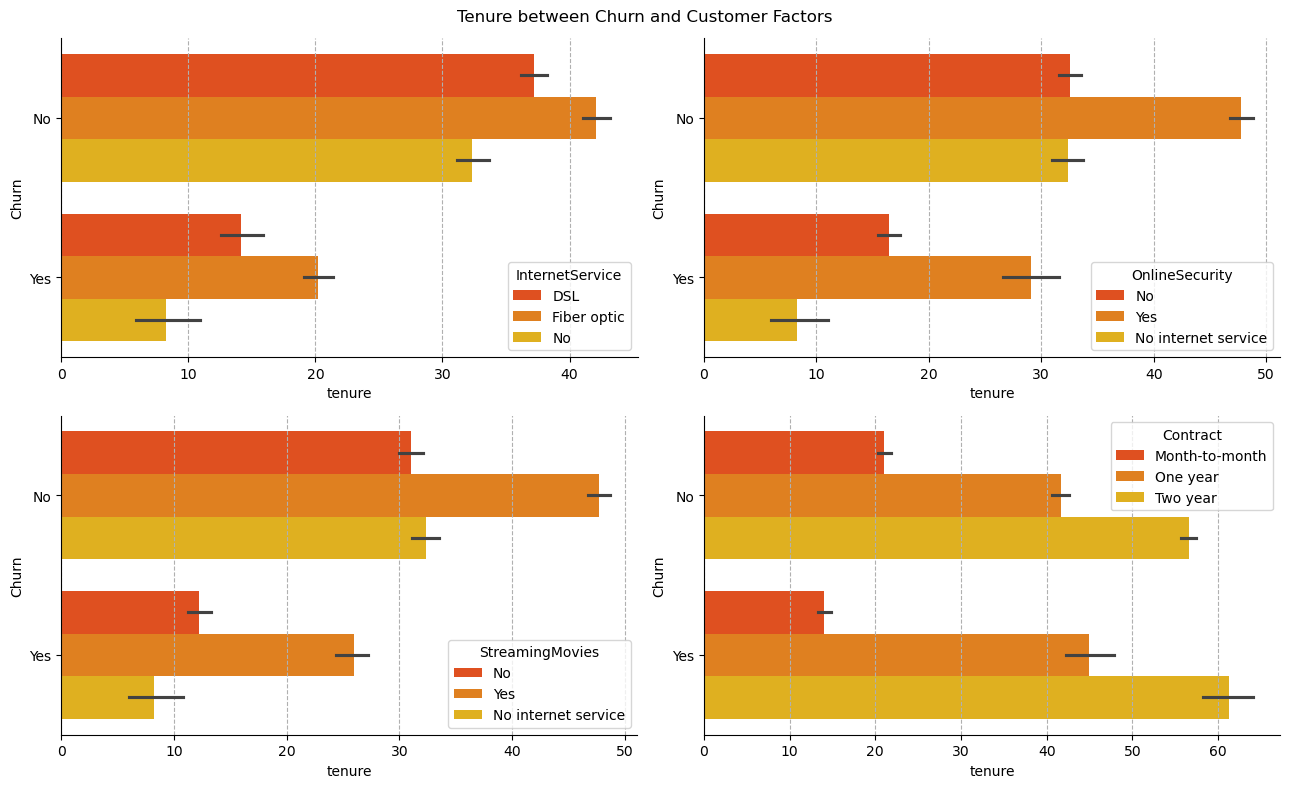

In [11]:
#

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
ax = ax.flatten()

sns.barplot(data, y='Churn', x='tenure', orient='y', hue='InternetService', palette='autumn', ax=ax[0])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].grid(axis='x', linestyle='--')

sns.barplot(data, y='Churn', x='tenure', orient='y', hue='OnlineSecurity', palette='autumn', ax=ax[1])
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].grid(axis='x', linestyle='--')

sns.barplot(data, y='Churn', x='tenure', orient='y', hue='StreamingMovies', palette='autumn', ax=ax[2])
ax[2].spines[['right', 'top']].set_visible(False)
ax[2].grid(axis='x', linestyle='--')

sns.barplot(data, y='Churn', x='tenure', orient='y', hue='Contract', palette='autumn', ax=ax[3])
ax[3].spines[['right', 'top']].set_visible(False)
ax[3].grid(axis='x', linestyle='--')

plt.suptitle("Tenure between Churn and Customer Factors")
plt.tight_layout()
plt.show()

### Encoding Binary Categorical Features

We will manually encode binary categorical features (those with only two unique values) into numerical representations (0 and 1).

In [35]:
bin_cat = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for item in bin_cat:
    if item == 'gender':
        data[item] = data[item].replace({'Female': 0, 'Male': 1})
    else:
        data[item] = data[item].replace({'Yes': 1, 'No': 0})

### Correlation Analysis of Numerical Features

We will calculate and visualize the correlation matrix for the numerical features to understand the linear relationships between them and the target variable `Churn`.

In [13]:
num_data = data[["tenure", "TotalCharges", "MonthlyCharges", "Churn"]].copy()
num_data["Churn"] = data["Churn"]
corr = num_data.corr(method='spearman')
corr

,tenure,TotalCharges,MonthlyCharges,Churn
tenure,1.000000,0.889696,0.276417,-0.367062
TotalCharges,0.889696,1.000000,0.638028,-0.229955
MonthlyCharges,0.276417,0.638028,1.000000,0.184743
Churn,-0.367062,-0.229955,0.184743,1.000000


### Box Plots of Numerical Features vs. Churn

Box plots will be used to visualize the distribution of numerical features (`tenure`, `TotalCharges`) for churned and non-churned customers, helping to identify differences between the two groups.

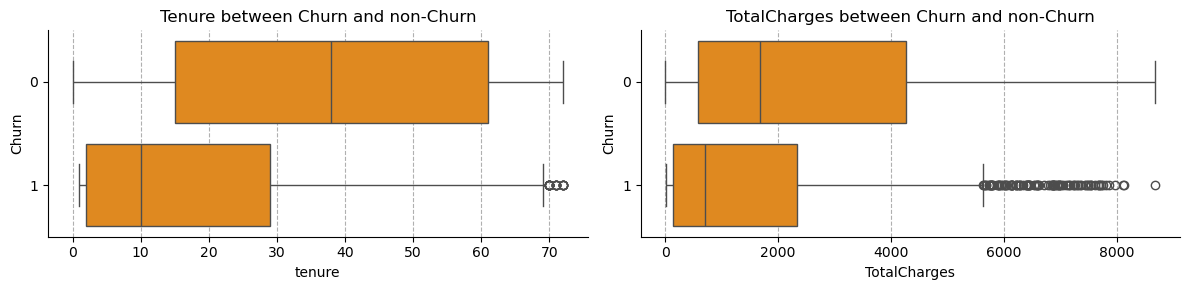

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax = ax.flatten()

sns.boxplot(data, x='tenure', y="Churn", color='darkorange', orient='h', ax=ax[0])
ax[0].set_title("Tenure between Churn and non-Churn")
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].grid(axis='x', linestyle='--')

sns.boxplot(data, x='TotalCharges', y="Churn", color='darkorange', orient='h', ax=ax[1])
ax[1].set_title("TotalCharges between Churn and non-Churn")
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()

## Data Imbalance

We will examine the distribution of the target variable `Churn` to identify any class imbalance, which is important to address for building an effective predictive model.

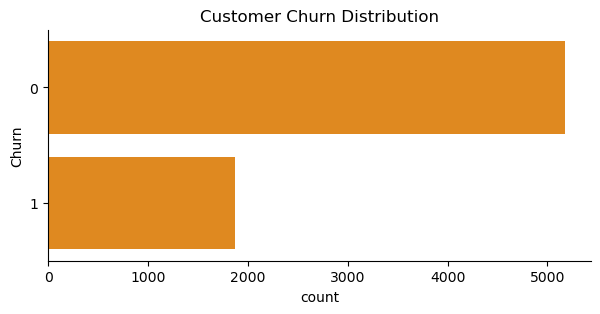

In [15]:
plt.figure(figsize=(7, 3))
ax = sns.countplot(data, y='Churn', color='darkorange')
plt.title("Customer Churn Distribution")
ax.spines[['right', 'top']].set_visible(False)
plt.show()

### Addressing Data Imbalance with Oversampling

To mitigate the issue of data imbalance, we will employ oversampling techniques to create synthetic samples for the minority class, ensuring a more balanced dataset for model training.

In [16]:
X = data.drop(['Churn', 'MonthlyCharges', 'gender', 'PhoneService'], axis=1)
y = data['Churn']

In [17]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy=1, random_state=42)
X_res, y_res = ros.fit_resample(X, y)

<Axes: ylabel='count'>

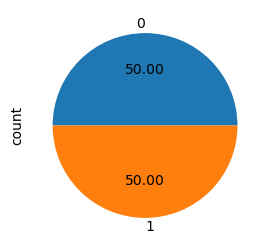

In [18]:
plt.figure(figsize=(6, 3))
y_res.value_counts().plot(kind='pie', autopct='%.2f')

### One-Hot Encoding of Categorical Features

We will split the data into training and testing sets then applying one-hot encoding to the remaining categorical features with more than two unique values.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
X_train_encod = encoder.fit_transform(X_train[cat])
X_test_encod = encoder.transform(X_test[cat])

In [20]:
X_train = X_train.drop(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'], axis=1)
X_train.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,TotalCharges
4541,1,0,0,1,0,50.55
5709,0,0,0,12,0,228.75
7393,0,0,0,35,0,2917.50
10026,1,1,0,36,1,3132.75
3578,0,0,0,40,0,2586.00


In [21]:
X_test = X_test.drop(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'], axis=1)

## Data Scaling
The data has only Three continous numeric features with each one of them has it's own range, therefor we need to scale them using `StandardScales` so the model does not give a priority for the one with bigger range and ignore the others

In [22]:
from sklearn.preprocessing import StandardScaler
num = ['tenure', 'TotalCharges']
ss = StandardScaler().set_output(transform='pandas')
X_train_scaled = ss.fit_transform(X_train[num])
X_test_scaled = ss.transform(X_test[num])

### Concatenating Scaled and Encoded Data

Finally, we combine the scaled numerical features, one-hot encoded categorical features, and the manually encoded binary features to create the final training and testing datasets for the machine learning models.

In [23]:
X_train_scaled = pd.concat([X_train_scaled, X_train_encod, X_train[['SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']]], axis=1)
X_train_scaled.head()

,tenure,TotalCharges,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,Partner,Dependents,PaperlessBilling
4541,-1.108680,-0.905470,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,0
5709,-0.650179,-0.823983,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0
7393,0.308506,0.405526,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0
10026,0.350188,0.503955,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1,1,0,1
3578,0.516915,0.253938,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0


In [24]:
X_test_scaled = pd.concat([X_test_scaled, X_test_encod, X_test[['SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']]], axis=1)

# ML Model

This section focuses on building and evaluating machine learning models for customer churn prediction.

In [25]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve, auc

## Model Selection

We will train and evaluate several classification models using cross-validation to identify the most promising algorithms for our churn prediction task.

In [26]:
models = {'log': LogisticRegression(), 'dt': DecisionTreeClassifier(), 'svc': SVC(probability=True), 'knn': KNeighborsClassifier(), 'rf': RandomForestClassifier(random_state=42)}

for name, item in models.items():
    scores = cross_val_score(item, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f'{name} score: {scores.mean():.2f}')

log score: 0.76
dt score: 0.84
svc score: 0.77
knn score: 0.75
rf score: 0.87


In [27]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## Hyperparameter Tuning with Grid Search

We will use Grid Search to find the optimal hyperparameters for the selected model(s) to improve their performance.

In [28]:
params = [{'n_estimators': [100, 150, 200],
           'max_depth': [None, 10, 20],
           'min_samples_split': [2, 5],
           'min_samples_leaf': [1, 2, 4],
           'max_features': [None, 'sqrt', 'log2']
          }]
gridsearch = GridSearchCV(rf, params, cv=5, n_jobs=-1)
gridsearch.fit(X_train_scaled, y_train)
print(f"best is: {gridsearch.best_params_}")

best is: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## Model Evaluation

We will evaluate the performance of the best-performing model using various metrics such as precision, recall, F1-score, and the ROC curve.

In [29]:
rf = RandomForestClassifier(random_state=42, max_depth=20, min_samples_leaf=1,
                            min_samples_split=2, n_estimators=100, max_features='sqrt')
rf.fit(X_train_scaled, y_train)
score = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'score: {score.mean():.2f}')
y_hat = rf.predict(X_test_scaled)

score: 0.87


In [30]:
print(f"percision score: {precision_score(y_test, y_hat, average='macro'):.2f}")
print(f"recall score: {recall_score(y_test, y_hat, average='macro'):.2f}")
print(f"f1 score: {f1_score(y_test, y_hat, average='macro'):.2f}")

percision score: 0.90
recall score: 0.90
f1 score: 0.90


### Confusion Matrix

We will visualize the confusion matrix to understand the model's performance in classifying churned and non-churned customers.

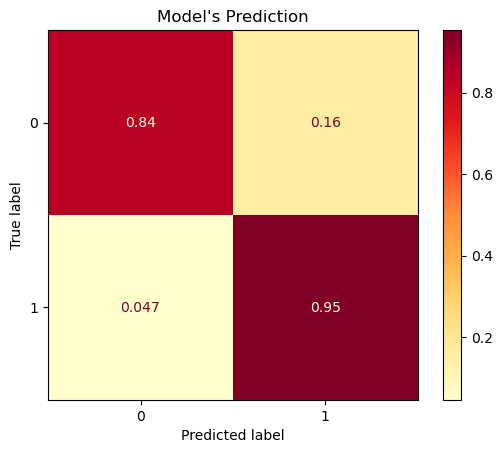

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, normalize='true', cmap='YlOrRd')
plt.title("Model's Prediction")
plt.show()

As `RandomForestClassifier` don't have `.decision_function()` we use `.predict_proba()` so we can get the model prediction before applying the threshold and returning `0` or `1`

In [32]:
decision_val = rf.predict_proba(X_test_scaled)[:, 1]

### ROC Curve and AUC

We will plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) to assess the model's ability to distinguish between the two classes.

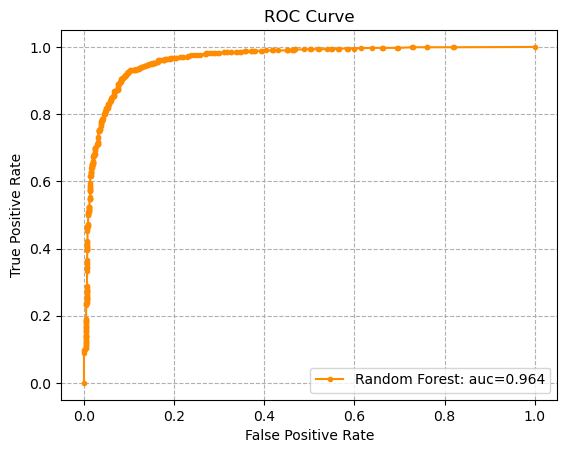

In [33]:
fpr, tpr, threshold = roc_curve(y_test, decision_val)
auc = auc(fpr, tpr)

plt.plot(fpr, tpr, marker='.', color='darkorange', label='Random Forest: auc=%0.3f'%auc)
plt.title("ROC Curve")
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.grid(linestyle='--')
plt.legend()
plt.show()

### Classification Report and Accuracy Score

We will generate a classification report to get a comprehensive overview of the model's performance across different metrics and calculate the overall accuracy score.

In [34]:
clf_rep = classification_report(y_test, y_hat)
acc = accuracy_score(y_test, y_hat)
print("Classification Report:")
print(clf_rep, '\n')
print(f"Accuracy Score: {acc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1021
           1       0.86      0.95      0.90      1049

    accuracy                           0.90      2070
   macro avg       0.90      0.90      0.90      2070
weighted avg       0.90      0.90      0.90      2070
 

Accuracy Score: 0.8981


## Conclusion and Key Findings

This notebook presented a comprehensive analysis and predictive modeling approach for customer churn. The key findings from the exploratory data analysis and model evaluation are:

*   **Data Cleaning and Preprocessing:** Missing values in `TotalCharges` were imputed, and the column was converted to a numerical type. Binary categorical features were manually encoded.
*   **Exploratory Data Analysis:**
    *   Numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) show skewed distributions, particularly `TotalCharges` and `tenure`, suggesting a large number of customers with short tenures and low total charges.
    *   Chi-squared tests revealed significant relationships between most categorical features and `Churn`, with the exceptions of `gender` and `PhoneService`.
    *   Tenure analysis showed that churn is more prevalent among customers with shorter tenures, particularly those with Fiber Optic internet service, no online security, and month-to-month contracts.
*   **Data Imbalance:** The dataset exhibited a class imbalance in the target variable `Churn`, which was addressed using Random Oversampling to create a balanced dataset for model training.
*   **Model Training and Evaluation:**
    *   Several classification models were evaluated using cross-validation, with `RandomForestClassifier` showing the highest average accuracy.
    *   Hyperparameter tuning using Grid Search was performed on the `RandomForestClassifier` to optimize its performance.
    *   The final `RandomForestClassifier` model achieved an accuracy of approximately 90% on the test set.
    *   The confusion matrix indicated that the model performs well in identifying both churned and non-churned customers, with a slightly higher recall for the churned class.
    *   The ROC curve and AUC score of 0.964 demonstrate the model's strong ability to discriminate between the two classes.

Overall, the `RandomForestClassifier` model built in this notebook provides a promising approach for predicting customer churn, leveraging insights gained from the data analysis and addressing the class imbalance issue. This model can be used to identify customers at high risk of churning, enabling proactive retention efforts.